In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

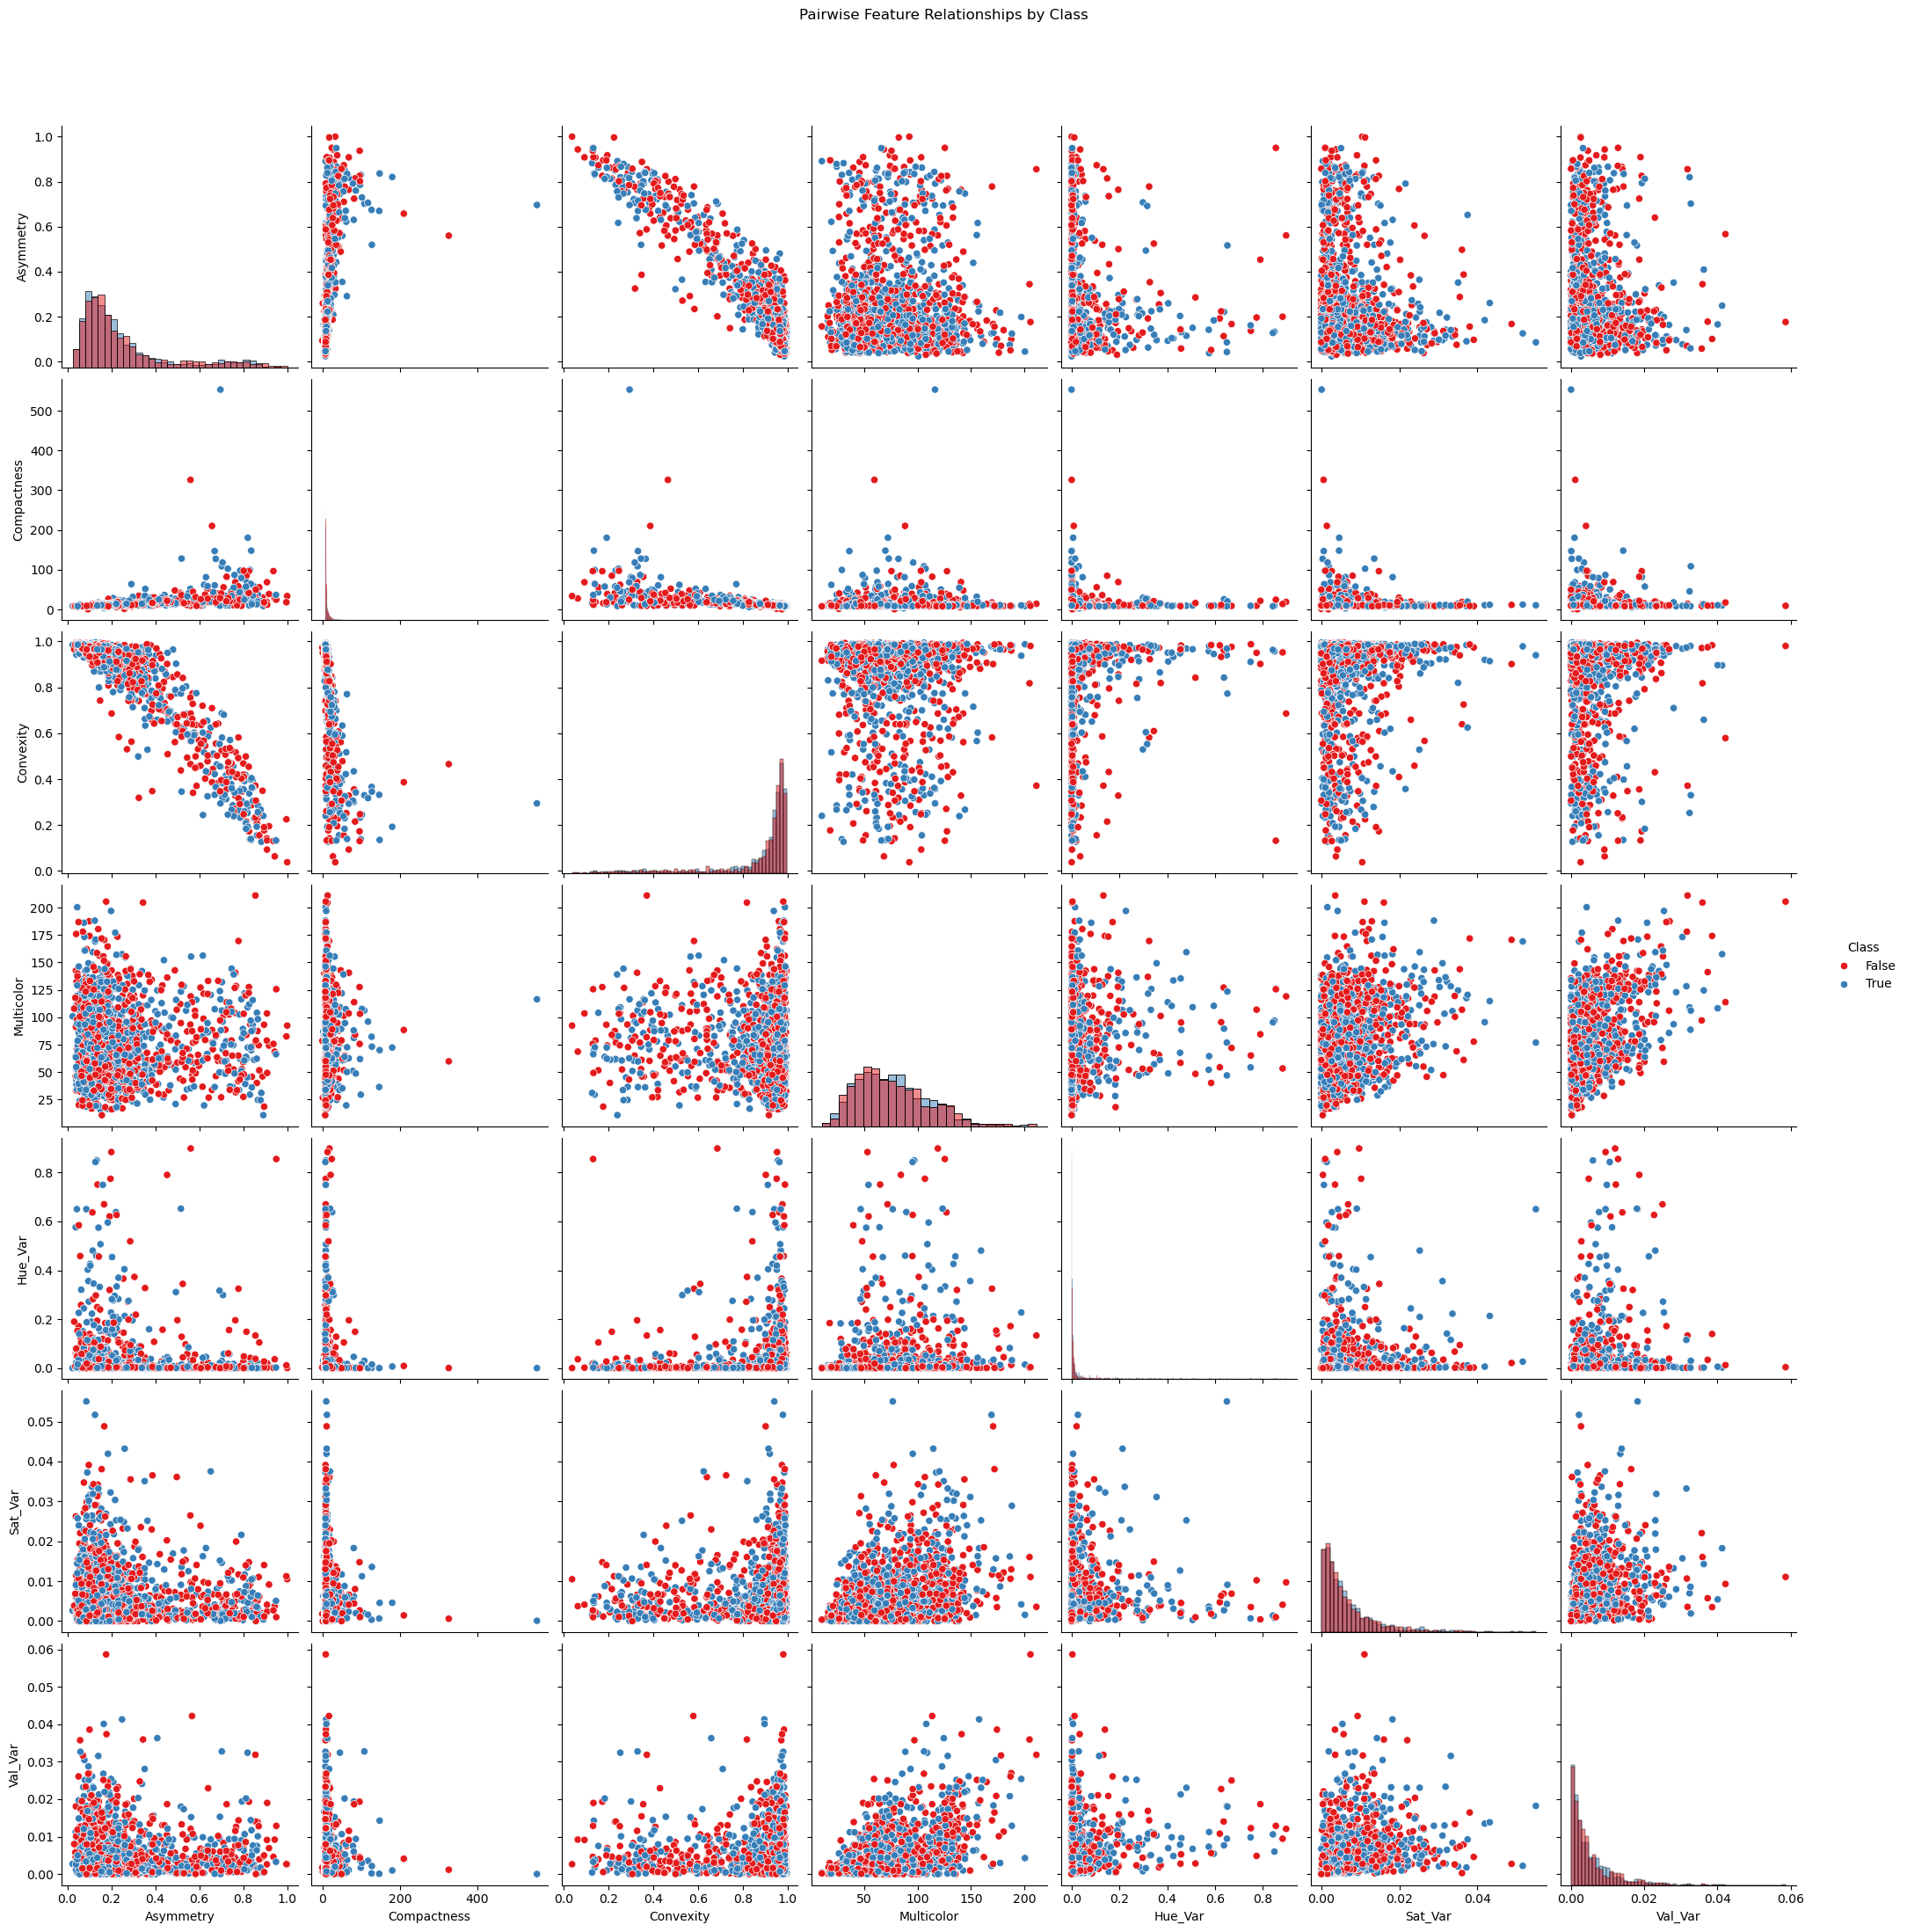

In [2]:
#pair plot
df=pd.read_csv("../data/extracted_features.csv")
df=df.drop(columns=["lesion_id", "patient_id", "filename"])
g = sns.pairplot(df, hue='Class', palette="Set1", height=3, diag_kind="hist")

g.fig.suptitle("Pairwise Feature Relationships by Class", y=1.05)

plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler
 
# List of features I want to scale
features = ["Compactness","Asymmetry", "Convexity", "Multicolor", "Hue_Var", "Sat_Var", "Val_Var",]
object = StandardScaler()
 
#Create a copy of df
df_scaled = df.copy()
 
# standardization
df_scaled[features] = object.fit_transform(df[features])
 

In [4]:


long_df = df_scaled.melt(
    id_vars="Class",
    var_name="feature",
    value_name="value"
)
long_df['value'] = pd.to_numeric(long_df['value'], errors='coerce')

Text(0.5, 1.0, 'Feature distribution by label')

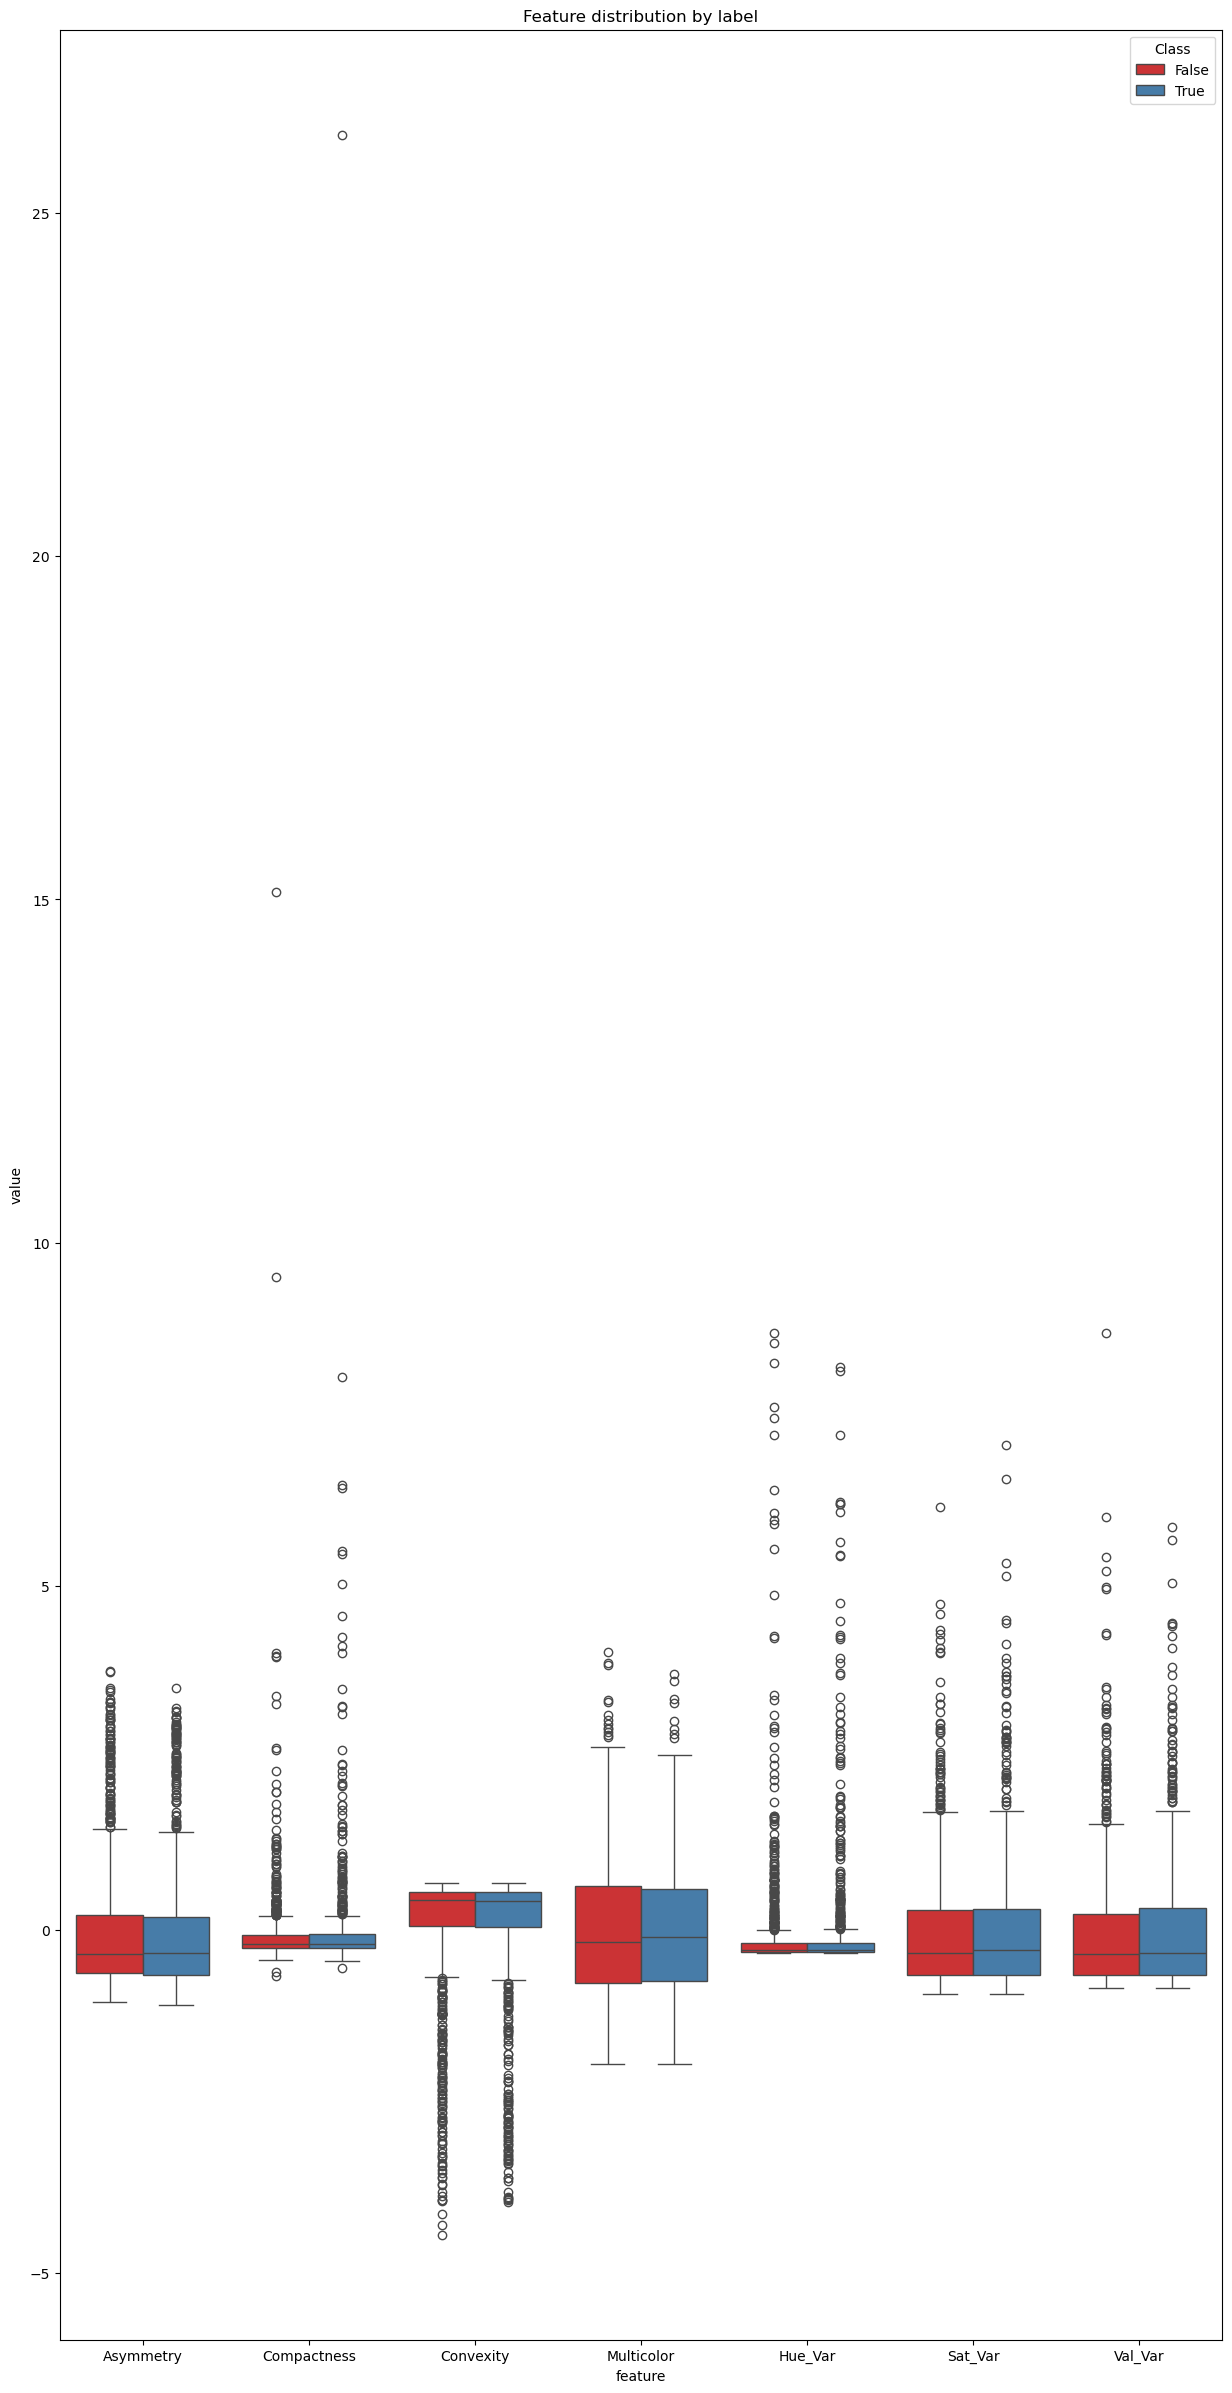

In [5]:
plt.figure(figsize=(15, 30))
ax = sns.boxplot(data=long_df, x="feature", y="value", hue="Class", palette="Set1")
ax.set_title("Feature distribution by label")

In [6]:
!pip install plotly

In [7]:
!pip install nbformat

In [8]:
pip install nbformat --upgrade

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [17]:
import plotly.express as px

# Forza la colonna Class a stringa per avere colori netti
df['Class'] = df['Class'].astype(str) 

features = ["Compactness", "Asymmetry", "Convexity", "Multicolor", "Hue_Var", "Sat_Var", "Val_Var"]

fig = px.scatter_3d(
    df, 
    x="Compactness", 
    y="Asymmetry", 
    z="Convexity",
    color="Class",
    opacity=0.8,
    template="plotly_dark",
    title="Esploratore 3D - Punti Piccoli"
)

# --- QUI IMPOSTI LA DIMENSIONE DEI PUNTI ---
# size=2 o 3 è l'ideale per dataset densi
fig.update_traces(marker=dict(size=3, line=dict(width=0))) 

def create_buttons(axis_name):
    return [
        dict(
            method="restyle",
            args=[{axis_name: [df[f]]}],
            label=f
        ) for f in features
    ]

fig.update_layout(
    updatemenus=[
        dict(buttons=create_buttons("x"), direction="down", x=0.1, xanchor="left", y=1.1, yanchor="top"),
        dict(buttons=create_buttons("y"), direction="down", x=0.4, xanchor="left", y=1.1, yanchor="top"),
        dict(buttons=create_buttons("z"), direction="down", x=0.7, xanchor="left", y=1.1, yanchor="top")
    ]
)

fig.show()